### Installation

In [1]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1" #
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth vllm
else:
    pass # For Colab / Kaggle, we need extra instructions hidden below \/

In [2]:
#@title Colab Extra Install { display-mode: "form" }
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; get_numpy = f"numpy=={numpy.__version__}"; get_pil = f"pillow=={PIL.__version__}"
    except: get_numpy = "numpy"; get_pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    get_vllm, get_triton = ("vllm==0.9.2", "triton==3.2.0") if is_t4 else ("vllm==0.10.2", "triton")
    !uv pip install -qqq --upgrade \
        unsloth {get_vllm} {get_numpy} {get_pil} torchvision bitsandbytes xformers
    !uv pip install -qqq {get_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2
!pip install protobuf==3.20.3 --upgrade --force-reinstall

### Unsloth

In [3]:
from huggingface_hub import login
login()

In [6]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 8192
lora_rank = 16

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct",
    max_seq_length = max_seq_length,
    load_in_4bit = False,
    fast_inference = True,
    gpu_memory_utilization = 0.6,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 01-18 20:52:19 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 01-18 20:52:32 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 01-18 20:52:32 [vllm_utils.py:731] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2026.1.3: Fast Qwen2 patching. Transformers: 4.56.2. vLLM: 0.10.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Standby mode is enabled. Changing `gpu_memory_utilization` to 0.925.
Unsloth: vLLM loading unsloth/Qwen2.5-7B-Instruct with actual GPU 

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 01-18 20:52:59 [__init__.py:1815] Using max model len 8192
INFO 01-18 20:53:02 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 01-18 20:53:02 [lora.py:92] `lora_extra_vocab_size` is deprecated and will be removed in v0.12.0. Additional vocabulary support for LoRA adapters is being phased out.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

In Unsloth, we share vLLM's weights directly, reducing VRAM usage by > 50%. vLLM also does not yet support LoRA on the vision layers, so we can only add them on the language layers. Vision GRPO still works though!

In [7]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0.0,
    use_rslora = False,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    use_gradient_checkpointing = "unsloth",
)

Unsloth 2026.1.3 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
module_names = [name for name, module in model.named_modules()]
print(module_names)

### Data Prep
<a name="Data"></a>

`ShenLab/MentalChat16K` is a benchmark dataset designed to support the development and evaluation of large language models (LLMs) for conversational mental health assistance. The dataset consists of 16,113 question-answer pairs, combining real anonymized interview transcripts from the PISCES clinical trial with synthetic dialogues generated by GPT-3.5 Turbo. This dataset covers a diverse range of mental health topics, including depression, anxiety, and grief, and aims to facilitate the creation of AI-driven mental health support tools.

In [8]:
from datasets import load_dataset
from trl import GRPOConfig, GRPOTrainer

dataset = load_dataset("ShenLab/MentalChat16K", split = "train")

subset_size = 10000
dataset = dataset.select(range(subset_size))

README.md: 0.00B [00:00, ?B/s]

Interview_Data_6K.csv:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

Synthetic_Data_10K.csv:   0%|          | 0.00/32.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16084 [00:00<?, ? examples/s]

We filter the dataset to keep only float or numeric answers:

In [9]:
dataset

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 10000
})

In [10]:
import re
REASONING_START = "<REASONING>"
REASONING_END = "</REASONING>"

SOLUTION_START = "<SOLUTION>"
SOLUTION_END = "</SOLUTION>"

SAMPLE_ID_START = "<SAMPLE_ID>"
SAMPLE_ID_END = "</SAMPLE_ID>"

SAMPLE_ID_RE = re.compile(rf"{re.escape(SAMPLE_ID_START)}\s*(\d+)\s*{re.escape(SAMPLE_ID_END)}")

def extract_sample_id(prompt_text: str):
    if not isinstance(prompt_text, str):
        return None
    m = SAMPLE_ID_RE.search(prompt_text)
    return int(m.group(1)) if m else None

def make_conversation(example, idx):
    user_prompt = (
        f"{example['input']}. Provide your reasoning thoughts between {REASONING_START} and {REASONING_END} "
        f"and your final answer between {SOLUTION_START} and {SOLUTION_END}."
    )
    user_prompt = f"{SAMPLE_ID_START}{idx}{SAMPLE_ID_END}\n" + user_prompt

    return {
        "prompt": user_prompt,
        "answer": example["output"],
        "sample_id": idx,
    }

train_dataset = dataset.map(make_conversation, with_indices=True)
train_dataset = train_dataset.remove_columns(["instruction"])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [11]:
train_dataset['prompt'][0]

"<SAMPLE_ID>0</SAMPLE_ID>\nI've been struggling with my mental health for a while now, and I can't seem to find a way to cope with it. I've tried visualization, positive thinking, and even medication, but nothing seems to work. I've been feeling lost and helpless, and I don't know what to do next. My mind is a whirlwind of thoughts and emotions, and I can't seem to make sense of it all. I feel like I'm drowning in a sea of confusion, and I can't seem to find my way out.. Provide your reasoning thoughts between <REASONING> and </REASONING> and your final answer between <SOLUTION> and </SOLUTION>."

Now let's apply the chat template across the entire dataset:

In [12]:
train_dataset = train_dataset.map(
    lambda example: {
        "prompt": tokenizer.apply_chat_template(
            [{"role": "user", "content": example["prompt"]}],
            tokenize=False,
            add_generation_prompt=True,
        ),
        "answer": example["answer"]
    }
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

## Reward functions


In [13]:
def contains_cjk(text):
    """If charset in text contains chineese japaneese of korean symbols"""
    ranges = [
        (0x4E00, 0x9FFF),
        (0x3400, 0x4DBF),
        (0x20000, 0x2A6DF),
        (0x2A700, 0x2B73F),
        (0x2B740, 0x2B81F),
        (0xF900, 0xFAFF),
        (0x2F800, 0x2FA1F),
    ]

    for char in text:
        code = ord(char)
        for start, end in ranges:
            if start <= code <= end:
                return True
    return False

In [14]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [16]:
from google.colab import drive
drive.mount("/content/drive")

import os, json, time, re, shutil
from datetime import datetime
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_DIR = "/content/drive/MyDrive/grpo_logs"
os.makedirs(DRIVE_DIR, exist_ok=True)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
DRIVE_LOG_PATH = os.path.join(DRIVE_DIR, f"run_{RUN_ID}.jsonl")
LOCAL_LOG_PATH = f"/content/run_{RUN_ID}.jsonl"

print("LOCAL_LOG_PATH:", LOCAL_LOG_PATH)
print("DRIVE_LOG_PATH:", DRIVE_LOG_PATH)

SPECIAL_RE = re.compile(r"</?[^>\s]+[^>]*>")

def extract_special_tokens(text: str):
    if not isinstance(text, str):
        return []
    return SPECIAL_RE.findall(text)

class JsonlLogger:
    def __init__(self, local_path: str, drive_path: str,
                 flush_every: int = 50, sync_every_flushes: int = 5):
        """
        flush_every: сколько записей буферим перед записью на диск (локально)
        sync_every_flushes: как часто копировать локальный файл на Drive (в flush-ах)
        """
        self.local_path = local_path
        self.drive_path = drive_path
        self.flush_every = int(flush_every)
        self.sync_every_flushes = int(sync_every_flushes)
        self._buffer = []
        self._flush_count = 0

    def log(self, record: dict):
        record = dict(record)
        record["ts"] = time.time()
        self._buffer.append(record)
        if len(self._buffer) >= self.flush_every:
            self.flush()

    def flush(self):
        if not self._buffer:
            return
        with open(self.local_path, "a", encoding="utf-8") as f:
            for r in self._buffer:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
        self._buffer = []
        self._flush_count += 1

        if self._flush_count % self.sync_every_flushes == 0:
            self.sync_to_drive()

    def sync_to_drive(self):
        if self._buffer:
            with open(self.local_path, "a", encoding="utf-8") as f:
                for r in self._buffer:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")
            self._buffer = []
        shutil.copy2(self.local_path, self.drive_path)

    def close(self):
        self.flush()
        self.sync_to_drive()

LOG_EVERY = 10
MAX_TEXT_CHARS = 1500

LOGGER = JsonlLogger(
    local_path=LOCAL_LOG_PATH,
    drive_path=DRIVE_LOG_PATH,
    flush_every=50,
    sync_every_flushes=4
)

_global_log_counter = 0


Mounted at /content/drive
LOCAL_LOG_PATH: /content/run_20260118_205657.jsonl
DRIVE_LOG_PATH: /content/drive/MyDrive/grpo_logs/run_20260118_205657.jsonl


In [17]:
BAD_PHRASES = [    "kill yourself","you should die","hurt yourself","self-harm",
    "take overdose","stop your medication","end your life","die now",
    "suicide","cut yourself","inject yourself","harm yourself",
    "drink poison","jump off","fatal","fatal injury","commit suicide",
    "die alone","die painlessly","self-destruction","die immediately"
]

CHINESE_TOP_WORDS = ['的', '是', '在', '和', '有', '不', '一', '了', '人', '我']

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

def embedding_distance_penalty(gold_answer, generated_answer):
    gold_embedding = embedding_model.encode([normalize_text(gold_answer)])[0]
    gen_embedding = embedding_model.encode([normalize_text(generated_answer)])[0]

    cosine_similarity = np.dot(gold_embedding, gen_embedding) / (np.linalg.norm(gold_embedding) * np.linalg.norm(gen_embedding))
    return cosine_similarity

_ws_re = re.compile(r'\s+')
_punct_re = re.compile(r'[^\w\s]', re.UNICODE)

def normalize_text(s: str, remove_punct: bool = True) -> str:
    s = s.lower().strip()
    s = _ws_re.sub(" ", s)
    if remove_punct:
        s = _punct_re.sub("", s)
    return s

def token_overlap_ratio(a: str, b: str) -> float:
    ta = normalize_text(a).split()
    tb = normalize_text(b).split()
    if not ta or not tb:
        return 0.0
    return len(set(ta).intersection(set(tb))) / max(1, len(set(ta).union(set(tb))))

def extract_tag(text: str, start_tag: str, end_tag: str):
    return re.findall(f"{re.escape(start_tag)}(.*?){re.escape(end_tag)}", text, re.DOTALL)

def formatting_reward_func(completions, **kwargs):
    scores = []
    for completion in completions:
        score = 0.0
        bf_flg, ch_flg = False, False
        reasoning_matches = extract_tag(completion, REASONING_START, REASONING_END)
        solution_matches = extract_tag(completion, SOLUTION_START, SOLUTION_END)
        if len(reasoning_matches) == 1:
            score += 2.0
        else:
            score -= 2.0
        if len(solution_matches) == 1:
            score += 2.0
        else:
            score -= 2.0
        if len(solution_matches) == 1 and len(solution_matches[0].split()) >= 10:
            score += 3.0
        else:
            score -= 2.0
        lower_text = completion.lower()
        for phrase in BAD_PHRASES:
            if phrase in lower_text:
                bf_flg = True
        score -= 3.0*bf_flg
        normalized_comp = normalize_text(completion)
        for word in CHINESE_TOP_WORDS:
            if word in normalized_comp:
                ch_flg = True
        score -= 3.0*ch_flg
        score -= 5.0*contains_cjk(lower_text)
        scores.append(score)
        bf_flg, ch_flg = False, False
    return scores

def correctness_reward_func(prompts, completions, answers, group_size: int = 1):
    rewards = []
    for i, prompt in enumerate(prompts):
        start = i * group_size
        end = start + group_size
        comps = completions[start:end]
        gold_answer = normalize_text(answers[i])

        for comp in comps:
            sol_matches = extract_tag(comp, SOLUTION_START, SOLUTION_END)
            if sol_matches:
                sol_text = normalize_text(sol_matches[0])
                if sol_text == gold_answer:
                    reward = 10.0
                else:
                    overlap = token_overlap_ratio(sol_text, gold_answer)
                    reward = 0.5 + 0.5 * overlap

                cosine_sim = embedding_distance_penalty(gold_answer, sol_text)
                total_scale_factor, reward_scale, balance_corr_wrong = 1.5, 1, 1
                reward += total_scale_factor*(reward_scale*cosine_sim - balance_corr_wrong)
            else:
                reward = -5.0

            rewards.append(reward)
    return rewards


def combined_reward(prompts, completions, answers=None, answer=None, **kwargs):

    global _global_log_counter

    group_size = kwargs.get("group_size", 1)
    if answers is None and answer is not None:
        answers = answer
    if answers is None:
        answers = [""] * len(prompts)

    fmt_scores = formatting_reward_func(completions)
    corr_scores = correctness_reward_func(
        prompts=prompts,
        completions=completions,
        answers=answers,
        group_size=group_size
    )

    fmt_coeff, corr_coeff = 0.8, 0.2
    totals = [fmt_coeff*f + corr_coeff*c for f, c in zip(fmt_scores, corr_scores)]

    for i in range(len(prompts)):
        p = prompts[i]
        gold = answers[i] if i < len(answers) else ""
        print(">>>GRP SIZE:", group_size)
        print(f">>>answers[{i}]:", gold)
        print(f">>>prompts[{i}]:", p)
        print(f">>>completions[{i}]:", completions[i])

        start = i * group_size
        end = start + group_size

        for j in range(start, min(end, len(completions))):
            _global_log_counter += 1
            if (_global_log_counter % LOG_EVERY) != 0:
                continue

            comp = completions[j]

            p_cut = p[:MAX_TEXT_CHARS] if isinstance(p, str) else p
            gold_cut = gold[:MAX_TEXT_CHARS] if isinstance(gold, str) else gold
            comp_cut = comp[:MAX_TEXT_CHARS] if isinstance(comp, str) else comp

            sid = extract_sample_id(p)
            rec = {
                "sample_id": sid,
                "reward": {
                    "fmt": float(fmt_scores[j]),
                    "corr": float(corr_scores[j]),
                    "total": float(totals[j]),
                },
                "prompt": p_cut,
                "answer": gold_cut,
                "completion": comp_cut,
                "special_tokens_completion": extract_special_tokens(comp),
                "special_tokens_answer": extract_special_tokens(gold),
            }

            LOGGER.log(rec)

    return totals

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Here is the first example prompt in the dataset

In [18]:
train_dataset[0]["prompt"]

"<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\n<SAMPLE_ID>0</SAMPLE_ID>\nI've been struggling with my mental health for a while now, and I can't seem to find a way to cope with it. I've tried visualization, positive thinking, and even medication, but nothing seems to work. I've been feeling lost and helpless, and I don't know what to do next. My mind is a whirlwind of thoughts and emotions, and I can't seem to make sense of it all. I feel like I'm drowning in a sea of confusion, and I can't seem to find my way out.. Provide your reasoning thoughts between <REASONING> and </REASONING> and your final answer between <SOLUTION> and </SOLUTION>.<|im_end|>\n<|im_start|>assistant\n"

<a name="Inference"></a>
### Inference

In [19]:

import torch
torch.cuda.empty_cache()

In [20]:
!nvidia-smi

Sun Jan 18 20:57:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             61W /  400W |   75039MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [21]:
from vllm import SamplingParams
sampling_params = SamplingParams(
    temperature = 1.0,
    top_k = 5,
    max_tokens = 1024,
)

outputs = model.fast_generate(
    {
        "prompt": train_dataset[100]["prompt"]
    },
    sampling_params,
)
print(outputs[0].outputs[0].text)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<REASONING>
The individual is expressing feelings of disconnection and difficulty adjusting to a new city, which is a common challenge for many people who move to different locations. They used to have a close-knit group of friends from their college, but now, due to the change in environment and possibly a lack of immediate social connections, they find it hard to maintain those relationships as they once did. This situation is likely affecting their mental health and sense of belonging, as human beings generally thrive on social connections and support networks.

To address this, it would be important to focus on building new social connections and re-establishing a feeling of community. This could involve joining clubs, groups, or activities that align with their interests, as this can help them meet people who share similar hobbies or goals. Additionally, reaching out to old friends via social media or video calls might help bridge the gap until they can meet in person again.

</RE

In [22]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [23]:
print(outputs[0].outputs[0].text)

reasoning_matches = extract_tag(outputs[0].outputs[0].text, REASONING_START, REASONING_END)
solution_matches = extract_tag(outputs[0].outputs[0].text, SOLUTION_START, SOLUTION_END)

print('\n', reasoning_matches, '\n')
print('\n', solution_matches, '\n')

<REASONING>
The individual is expressing feelings of disconnection and difficulty adjusting to a new city, which is a common challenge for many people who move to different locations. They used to have a close-knit group of friends from their college, but now, due to the change in environment and possibly a lack of immediate social connections, they find it hard to maintain those relationships as they once did. This situation is likely affecting their mental health and sense of belonging, as human beings generally thrive on social connections and support networks.

To address this, it would be important to focus on building new social connections and re-establishing a feeling of community. This could involve joining clubs, groups, or activities that align with their interests, as this can help them meet people who share similar hobbies or goals. Additionally, reaching out to old friends via social media or video calls might help bridge the gap until they can meet in person again.

</RE

<a name="Train"></a>
### Train the model

In [24]:
from trl import GRPOConfig

training_args = GRPOConfig(
    learning_rate=5e-6,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.000001,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",

    logging_steps=1,
    log_completions=False,

    per_device_train_batch_size=4,
    gradient_accumulation_steps = 1,
    num_generations=2,

    max_prompt_length=1024,
    max_completion_length=1024,

    num_train_epochs = 2,
    max_steps=4500,
    save_steps=200,
    save_total_limit=3,

    max_grad_norm=0.1,
    report_to="none",

    output_dir="/content/drive/MyDrive/grpo_ckpts/outputs",

    importance_sampling_level="sequence",
    mask_truncated_completions=False,
    loss_type="dr_grpo",
)


And let's run the trainer! If you scroll up, you'll see a table of rewards. The goal is to see the `reward` column increase!

You might have to wait 150 to 200 steps for any action. You'll probably get 0 reward for the first 100 steps. Please be patient!

| Step | Training Loss | reward    | reward_std | completion_length | kl       |
|------|---------------|-----------|------------|-------------------|----------|
| 1    | 0.000000      | 0.125000  | 0.000000   | 200.000000        | 0.000000 |
| 2    | 0.000000      | 0.072375  | 0.248112   | 200.000000        | 0.000000 |
| 3    | 0.000000      | -0.079000 | 0.163776   | 182.500000        | 0.000005 |

During inference, you might encounter `addCriterion` or some weird gibberish outputs. Please read our [blog post](https://docs.unsloth.ai/new/vision-reinforcement-learning-vlm-rl#qwen-2.5-vl-vision-rl-issues-and-quirks) on why this occurs. It seems to be an inherent thing inside of the model, and we can ignore this.

In [25]:
from transformers import TrainerCallback
import shutil, os

class PushLoraToHubCallback(TrainerCallback):
    def __init__(self, repo_id, every_steps=200):
        self.repo_id = repo_id
        self.every_steps = every_steps
        self.tmp_dir = "lora_tmp"

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step > 0 and state.global_step % self.every_steps == 0:
            model = kwargs["model"]
            tokenizer = kwargs.get("tokenizer", None)

            if os.path.exists(self.tmp_dir):
                shutil.rmtree(self.tmp_dir)
            os.makedirs(self.tmp_dir, exist_ok=True)

            model.save_pretrained(
                self.tmp_dir,
                safe_serialization=True,
                push_to_hub=True,
                repo_id=self.repo_id,
                commit_message=f"LoRA step {state.global_step}",
            )
            if tokenizer is not None:
                tokenizer.save_pretrained(
                    self.tmp_dir,
                    push_to_hub=True,
                    repo_id=self.repo_id,
                )

            print(f"[HF Hub] LoRA pushed at step {state.global_step}")

        return control

In [26]:
trainer = GRPOTrainer(
    model=model,
    args=training_args,
    processing_class=tokenizer,
    reward_funcs=[combined_reward],
    train_dataset=train_dataset
)
trainer.add_callback(
    PushLoraToHubCallback(
        repo_id="NataliiaTarasiuk/qwen2.5-7b-mental-lora",
        every_steps=200
    )
)


trainer.train()
LOGGER.close()
print("Logs saved to Drive:", DRIVE_LOG_PATH)


model.save_pretrained(
    "lora_tmp",
    safe_serialization=True,
    push_to_hub=True,
    repo_id="NataliiaTarasiuk/qwen2.5-7b-mental-lora"
)
tokenizer.save_pretrained(
    "lora_tmp",
    push_to_hub=True,
    repo_id="NataliiaTarasiuk/qwen2.5-7b-mental-lora"
)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 4,500
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Unsloth: Will smartly offload gradients to save VRAM!
>>>GRP SIZE: 1
>>>answers[0]: I can see how deeply committed you are to your sister's well-being, and I understand the emotional toll that caregiving can take on you. It's essential to find a balance between your caregiving responsibilities and your own self-care and relationships. You've been doing an incredible job as a caregiver, but it's important to remember that you can't do it all alone. Have you considered reaching out to local caregiver support groups or hiring professional caregivers for respite care? These resources can provide you with much-needed relief and allow you to maintain your connections with your family and friends. Additionally, it's crucial to explore alternative solutions for your sister's care, such as teaching her new skills or implementing safety measures in her environment, to help her become more independent and reduce your caregiving burden. Remember, taking care of yourself is not only essential for y

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / combined_reward / mean,rewards / combined_reward / std
1,-0.004300,1.533602,5.845796,535.750000,506.000000,578.000000,0.000000,535.750000,506.000000,578.000000,0.000000,1.533602,4.773078
2,-0.028000,0.723932,6.963491,462.000000,315.000000,528.000000,0.000000,462.000000,315.000000,528.000000,0.000000,0.723932,5.833879
3,-0.033800,5.645502,0.011513,519.500000,375.000000,642.000000,0.000000,519.500000,375.000000,642.000000,0.000351,5.645502,0.020472
4,-0.009800,-1.332184,4.055704,586.000000,504.000000,643.000000,0.000000,586.000000,504.000000,643.000000,0.000777,-1.332184,4.906607
5,-0.038500,-0.281796,8.369604,560.250000,426.000000,763.000000,0.000000,560.250000,426.000000,763.000000,0.000883,-0.281796,7.439115
6,-0.036400,-1.340319,4.044200,534.750000,457.000000,717.000000,0.000000,534.750000,457.000000,717.000000,0.000689,-1.340319,4.891128
7,-0.053800,5.657392,0.018863,508.000000,346.000000,639.000000,0.000000,508.000000,346.000000,639.000000,0.000857,5.657392,0.020394
8,-0.006300,2.794278,4.037304,465.000000,375.000000,572.000000,0.000000,465.000000,375.000000,572.000000,0.000806,2.794278,5.729603
9,0.007400,1.507091,5.808304,398.250000,335.000000,440.000000,0.000000,398.250000,335.000000,440.000000,0.000823,1.507091,4.742500
10,-0.011000,2.725940,4.092545,483.500000,284.000000,651.000000,0.000000,483.500000,284.000000,651.000000,0.000952,2.725940,5.684580


Выходные данные были обрезаны до нескольких последних строк (5000).
Coping-wise, I have tried engaging in activities that previously brought joy, such as spending time with loved ones or taking walks in nature. While these efforts provide temporary relief, they don't alleviate the underlying feelings of emptiness and despair that persistently linger.

As we embark on this counseling journey together, I would like to discuss different therapeutic approaches or interventions aimed at treating depression. Are there any particular techniques or strategies you find successful for individuals experiencing similar symptoms?. Provide your reasoning thoughts between <REASONING> and </REASONING> and your final answer between <SOLUTION> and </SOLUTION>.<|im_end|>
<|im_start|>assistant

>>>completions[3]: <REASONING>
Your experience of depression following the sudden loss of a close family member is quite common and often associated with complicated grief. Depression can significantly affect how o

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  lora_tmp/tokenizer.json     : 100%|##########| 11.4MB / 11.4MB            

('lora_tmp/tokenizer_config.json',
 'lora_tmp/special_tokens_map.json',
 'lora_tmp/chat_template.jinja',
 'lora_tmp/vocab.json',
 'lora_tmp/merges.txt',
 'lora_tmp/added_tokens.json',
 'lora_tmp/tokenizer.json')

In [35]:
class GRPOLogAnalyzer:
    def __init__(self, jsonl_path: str):
        self.path = jsonl_path
        self.df = None

    def load(self):
        rows = []
        with open(self.path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
        self.df = pd.json_normalize(rows)

        for col in ["reward.fmt", "reward.corr", "reward.total"]:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors="coerce")

        self.df["step"] = range(len(self.df))
        return self.df

    def plot_rewards(self, window: int = 50):
        if self.df is None:
            self.load()

        plt.figure()
        plt.plot(self.df["step"], self.df["reward.total"], label="total")
        plt.plot(self.df["step"], self.df["reward.fmt"], label="fmt")
        plt.plot(self.df["step"], self.df["reward.corr"], label="corr")
        plt.legend()
        plt.xlabel("log step")
        plt.ylabel("reward")
        plt.title("Rewards over time")
        plt.show()

        if window and window > 1:
            plt.figure()
            for k in ["reward.total", "reward.fmt", "reward.corr"]:
                plt.plot(self.df["step"], self.df[k].rolling(window).mean(), label=f"{k} (ma{window})")
            plt.legend()
            plt.xlabel("log step")
            plt.ylabel("reward (moving avg)")
            plt.title(f"Rewards moving average (window={window})")
            plt.show()

    def top_special_tokens(self, field="special_tokens_completion", topn=30):
        if self.df is None:
            self.load()
        c = Counter()
        if field not in self.df.columns:
            print(f"No column '{field}' in logs.")
            return []
        for arr in self.df[field].dropna():
            if isinstance(arr, list):
                c.update(arr)
            elif isinstance(arr, str):
                c.update(extract_special_tokens(arr))
        return c.most_common(topn)

    def worst_samples(self, n=20):
        if self.df is None:
            self.load()
        if "sample_id" not in self.df.columns:
            print("No sample_id in logs.")
            return None
        agg = (self.df.groupby("sample_id")["reward.total"]
               .mean()
               .sort_values()
               .head(n))
        return agg


    def new_tokens_over_time(self, field="special_tokens_completion", every=200):
        if self.df is None:
            self.load()
        if field not in self.df.columns:
            print(f"No column '{field}' in logs.")
            return []

        seen = set()
        report = []
        for start in range(0, len(self.df), every):
            chunk = self.df.iloc[start:start+every]
            chunk_tokens = set()
            for arr in chunk[field].dropna():
                if isinstance(arr, list):
                    chunk_tokens.update(arr)
                elif isinstance(arr, str):
                    chunk_tokens.update(extract_special_tokens(arr))
            new = sorted(list(chunk_tokens - seen))
            if new:
                report.append({
                    "start_step": int(start),
                    "end_step": int(min(start+every, len(self.df))),
                    "new_tokens": new
                })
            seen |= chunk_tokens
        return report


   sample_id                                             prompt  \
0        331  <|im_start|>system\nYou are Qwen, created by A...   
1       8541  <|im_start|>system\nYou are Qwen, created by A...   
2        918  <|im_start|>system\nYou are Qwen, created by A...   

                                              answer  \
0  I can empathize with the challenges you've bee...   
1  One strategy that might help you manage your a...   
2  It's common for caregivers to experience feeli...   

                                          completion  \
0  <REASONING>\nThe individual is experiencing ch...   
1  <REASONING>\nFrom the given sample ID and the ...   
2  <REASONING>\nI understand the complexity of th...   

                           special_tokens_completion special_tokens_answer  \
0  [<REASONING>, <span style="color:blue">, </spa...                    []   
1            [<REASONING>, </REASONING>, <SOLUTION>]                    []   
2  [<REASONING>, </REASONING>, <SOLUTION>, </SO

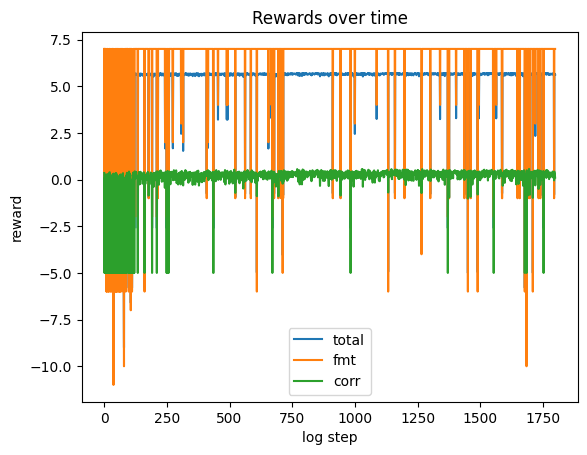

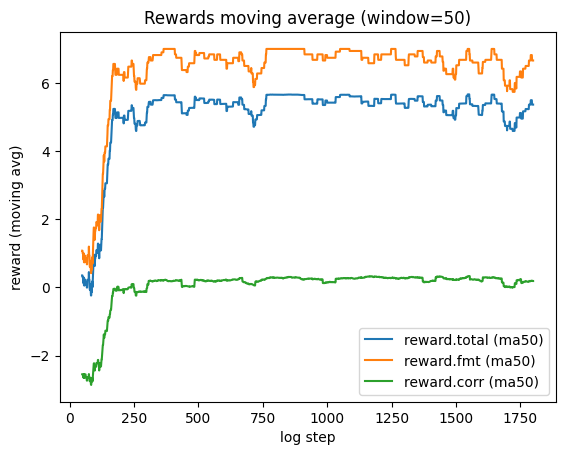


Top completion special tokens:
[('<REASONING>', 1809), ('<SOLUTION>', 1798), ('</REASONING>', 1780), ('</SOLUTION>', 1725), ('<li>', 4), ('</li>', 4), ('<PARAGRAPH>', 3), ('</PARAGRAPH>', 3), ('<RESOURCE>', 2), ('<span style="color:blue">', 1), ('</span>', 1), ('<I mkdir="ignore_case">', 1), ('<THERAPIES所所长>', 1), ('</THERAPIES所所长>', 1), ('<COMMENTARY>', 1), ('<RECOMMENDATIONS>', 1), ('</RECOMMENDATIONS>', 1), ('<RESOURCES>', 1), ('<STRUCTURE>', 1), ('<SIONAL>', 1), ('<ANSWER>', 1), ('<ＳＯＬＵＴＩＯＮ>', 1), ('<GREETINGS>', 1), ('</GREETINGS>', 1), ('<\\Controllers>', 1), ('<RECOMMENDED_STEPS>', 1), ('</RECOMMENDED_STEPS>', 1), ('<p惰于处理这些繁杂的事务确实是这个困难时期的一重负担。以下是一些建议，希望能帮助您更有效地管理这些任务，并给予您一些心理上的支持。</p>', 1), ('<ul>', 1), ('</ul>', 1)]

New tokens over time:
0 - 200 : ['</GREETINGS>', '</REASONING>', '</RECOMMENDATIONS>', '</SOLUTION>', '</THERAPIES所所长>', '</span>', '<ANSWER>', '<COMMENTARY>', '<GREETINGS>', '<I mkdir="ignore_case">', '<REASONING>', '<RECOMMENDATIONS>', '<RESOURCE>', '<RESOURCES

In [36]:
an = GRPOLogAnalyzer(DRIVE_LOG_PATH)
df = an.load()
print(df.head(3))

an.plot_rewards(window=50)

print("\nTop completion special tokens:")
print(an.top_special_tokens("special_tokens_completion", topn=30))

print("\nNew tokens over time:")
for r in an.new_tokens_over_time(every=200):
    print(r["start_step"], "-", r["end_step"], ":", r["new_tokens"][:15], ("..." if len(r["new_tokens"])>15 else ""))

print(an.worst_samples(20))

<a name="Inference"></a>
### Inference



And now with the LoRA we just trained with GRPO - we first save the LoRA first!

In [29]:
import os

DRIVE_DIR = "/content/drive/MyDrive/lora/grpo_lora"
os.makedirs(DRIVE_DIR, exist_ok=True)

model.save_lora(DRIVE_DIR)
model.save_pretrained(DRIVE_DIR, safe_serialization=True)
tokenizer.save_pretrained(DRIVE_DIR)

('/content/drive/MyDrive/lora/grpo_lora/tokenizer_config.json',
 '/content/drive/MyDrive/lora/grpo_lora/special_tokens_map.json',
 '/content/drive/MyDrive/lora/grpo_lora/chat_template.jinja',
 '/content/drive/MyDrive/lora/grpo_lora/vocab.json',
 '/content/drive/MyDrive/lora/grpo_lora/merges.txt',
 '/content/drive/MyDrive/lora/grpo_lora/added_tokens.json',
 '/content/drive/MyDrive/lora/grpo_lora/tokenizer.json')

In [30]:
model.save_lora("grpo_lora")
tokenizer.save_pretrained("grpo_tokenizer")

('grpo_tokenizer/tokenizer_config.json',
 'grpo_tokenizer/special_tokens_map.json',
 'grpo_tokenizer/chat_template.jinja',
 'grpo_tokenizer/vocab.json',
 'grpo_tokenizer/merges.txt',
 'grpo_tokenizer/added_tokens.json',
 'grpo_tokenizer/tokenizer.json')







We try calling vLLM with our trained RL model:

In [31]:
from vllm import SamplingParams
sampling_params = SamplingParams(
    temperature = 1.0,
    top_k = 50,
    max_tokens = 1024,
)

outputs = model.fast_generate(
    {"prompt": train_dataset[165]["prompt"]},
    sampling_params,
    lora_request=model.load_lora("grpo_lora")
)
print(outputs[0].outputs[0].text)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<REASONING>
Deciding on a hospice facility can indeed be a challenging process, especially when you need to consider multiple factors such as location, services offered, staff credentials, patient reviews, and personal preferences. It's understandable to feel overwhelmed and anxious about the process, particularly when you're concerned about making a wrong decision. Managing this anxiety and ensuring you have all necessary information can help alleviate some of the stress.
</REASONING>

<SOLUTION>
It sounds like you're experiencing a lot of stress as you compare different hospice facilities, which is entirely normal given the importance of this decision. Here are a few steps you can take to help manage this process and ease your anxiety:

1. **Organize Your Information**: Create a system to keep track of the details and information you gather from each facility. You might use spreadsheets, note-taking apps, or simple lists. This can help you remember the factors that are most important

Verify LoRA is actually trained!

In [32]:
from safetensors import safe_open

tensors = {}
with safe_open("grpo_lora/adapter_model.safetensors", framework = "pt") as f:
    for key in f.keys():
        tensor = f.get_tensor(key)
        n_zeros = (tensor == 0).sum() / tensor.numel()
        assert(n_zeros.item() != tensor.numel())